# 03 — Fairness Evaluation

## Purpose

This notebook evaluates subgroup performance and fairness metrics across age groups for the baseline resume-screening model trained in `02_model_training.ipynb`.

## What We Measure

- Outcome rates by age group (e.g., predicted callback rate)
- Error rates by group (FPR, FNR)
- Fairness metrics such as:
  - Statistical Parity Difference
  - Disparate Impact Ratio
  - Equal Opportunity Difference (TPR difference)

## Important Constraint

Age-related fields are used here only for evaluation. They were excluded from model training by design.

## Imports and Configuration

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

sns.set(style="whitegrid")

## Load Dataset and Trained Model(s)

In [4]:
predictions_path = PROJECT_ROOT / "data" / "baseline" / "logreg_with_grad_year_predictions.parquet"
pred_df = pd.read_parquet(predictions_path)

print(pred_df.shape)
pred_df.head()

(2000, 55)


,application_year,target_role_family,target_role_level,region,highest_degree,graduation_year,school_tier,gpa_bucket,years_experience_total,years_experience_relevant,...,quantified_impact_count,keyword_match_score,format_clean_score,salary_expectation_usd,willing_to_relocate,remote_only,y_true,y_pred,y_prob,age_group
0,2025,Security,Senior,Other,None,1994,1,3.0-3.4,29.731905,23.402689,...,2,0.870359,0.847066,366212,True,False,1,1,0.993929,50-59
1,2025,Sales,Entry,EU,HS,2015,3,3.5-3.7,8.187666,6.336264,...,3,0.624753,0.905992,138828,True,True,0,0,0.023629,30-39
2,2025,Security,Director,US-Central,BS,2018,1,3.8+,8.137028,7.213655,...,3,0.975682,0.882748,136815,True,False,1,1,0.999810,30-39
3,2025,SWE,Manager,US-Central,PhD,2008,5,3.0-3.4,16.506363,15.363270,...,4,0.477370,0.747738,231369,True,True,0,0,0.000279,30-39
4,2025,SWE,Staff,EU,AA,1998,4,unknown,24.499619,22.216576,...,4,0.682740,0.971681,305656,False,False,0,0,0.318094,40-49


In [5]:
required_cols = ["y_true", "y_pred", "y_prob", "age_group"]
missing = [c for c in required_cols if c not in pred_df.columns]
assert not missing, f"Missing required columns: {missing}"

pred_df["y_true"] = pred_df["y_true"].astype(int)
pred_df["y_pred"] = pred_df["y_pred"].astype(int)

In [6]:
pred_df["age_group"].value_counts().sort_index()

age_group
<30      524
30-39    568
40-49    499
50-59    307
60+      102
Name: count, dtype: int64

## Generate Predictions

## Overall Metrics Recap

In [7]:
overall_callback_rate = pred_df["y_pred"].mean()
overall_actual_rate = pred_df["y_true"].mean()

print(f"Overall predicted callback rate: {overall_callback_rate:.3f}")
print(f"Overall actual callback rate:    {overall_actual_rate:.3f}")

Overall predicted callback rate: 0.382
Overall actual callback rate:    0.400


## Grouped Outcome Rates (By Age Group)

In [8]:
group_outcomes = (
    pred_df.groupby("age_group", observed=False)
    .agg(
        n=("y_true", "size"),
        actual_callback_rate=("y_true", "mean"),
        predicted_callback_rate=("y_pred", "mean"),
        avg_predicted_probability=("y_prob", "mean"),
    )
    .reset_index()
)

group_outcomes

,age_group,n,actual_callback_rate,predicted_callback_rate,avg_predicted_probability
0,<30,524,0.229008,0.215649,0.225350
1,30-39,568,0.489437,0.410211,0.419766
2,40-49,499,0.298597,0.364729,0.367483
3,50-59,307,0.573290,0.563518,0.563333
4,60+,102,0.754902,0.617647,0.652826


## Grouped Error Rates (FPR/FNR/TPR)

In [9]:
def compute_group_classification_metrics(df_group: pd.DataFrame) -> pd.Series:
    y_true = df_group["y_true"].astype(int)
    y_pred = df_group["y_pred"].astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fnr = fn / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    tnr = tn / (fp + tn) if (fp + tn) > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    selection_rate = y_pred.mean()

    return pd.Series({
        "n": len(df_group),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "tpr": tpr,
        "fnr": fnr,
        "fpr": fpr,
        "tnr": tnr,
        "precision": precision,
        "selection_rate": selection_rate,
    })

In [10]:
group_error_metrics = (
    pred_df.groupby("age_group", observed=False)
    .apply(compute_group_classification_metrics)
    .reset_index()
)

group_error_metrics

,age_group,n,tp,fp,tn,fn,tpr,fnr,fpr,tnr,precision,selection_rate
0,<30,524.0,109.0,4.0,400.0,11.0,0.908333,0.091667,0.009901,0.990099,0.964602,0.215649
1,30-39,568.0,233.0,0.0,290.0,45.0,0.838129,0.161871,0.000000,1.000000,1.000000,0.410211
2,40-49,499.0,147.0,35.0,315.0,2.0,0.986577,0.013423,0.100000,0.900000,0.807692,0.364729
3,50-59,307.0,171.0,2.0,129.0,5.0,0.971591,0.028409,0.015267,0.984733,0.988439,0.563518
4,60+,102.0,63.0,0.0,25.0,14.0,0.818182,0.181818,0.000000,1.000000,1.000000,0.617647


## Fairness Metrics (Parity, Impact, Equal Opportunity)

In [11]:
REFERENCE_GROUP = "30-39"

In [12]:
def get_reference_value(df: pd.DataFrame, metric: str, reference_group: str):
    row = df.loc[df["age_group"] == reference_group, metric]
    if row.empty:
        raise ValueError(f"Reference group '{reference_group}' not found.")
    return row.iloc[0]

In [13]:
ref_selection_rate = get_reference_value(group_error_metrics, "selection_rate", REFERENCE_GROUP)

group_fairness = group_error_metrics[["age_group", "selection_rate", "tpr"]].copy()
group_fairness["statistical_parity_difference"] = group_fairness["selection_rate"] - ref_selection_rate

In [14]:
group_fairness["disparate_impact_ratio"] = group_fairness["selection_rate"] / ref_selection_rate

In [15]:
ref_tpr = get_reference_value(group_fairness, "tpr", REFERENCE_GROUP)
group_fairness["equal_opportunity_difference"] = group_fairness["tpr"] - ref_tpr

In [16]:
group_fairness

,age_group,selection_rate,tpr,statistical_parity_difference,disparate_impact_ratio,equal_opportunity_difference
0,<30,0.215649,0.908333,-0.194562,0.525702,0.070204
1,30-39,0.410211,0.838129,0.000000,1.000000,0.000000
2,40-49,0.364729,0.986577,-0.045482,0.889126,0.148448
3,50-59,0.563518,0.971591,0.153307,1.373726,0.133461
4,60+,0.617647,0.818182,0.207436,1.505680,-0.019948


## Summary Table

In [17]:
fairness_summary = (
    group_outcomes
    .merge(group_error_metrics, on="age_group", suffixes=("_outcome", "_error"))
    .merge(
        group_fairness[[
            "age_group",
            "statistical_parity_difference",
            "disparate_impact_ratio",
            "equal_opportunity_difference"
        ]],
        on="age_group"
    )
)

fairness_summary

,age_group,n_outcome,actual_callback_rate,predicted_callback_rate,avg_predicted_probability,n_error,tp,fp,tn,fn,tpr,fnr,fpr,tnr,precision,selection_rate,statistical_parity_difference,disparate_impact_ratio,equal_opportunity_difference
0,<30,524,0.229008,0.215649,0.225350,524.0,109.0,4.0,400.0,11.0,0.908333,0.091667,0.009901,0.990099,0.964602,0.215649,-0.194562,0.525702,0.070204
1,30-39,568,0.489437,0.410211,0.419766,568.0,233.0,0.0,290.0,45.0,0.838129,0.161871,0.000000,1.000000,1.000000,0.410211,0.000000,1.000000,0.000000
2,40-49,499,0.298597,0.364729,0.367483,499.0,147.0,35.0,315.0,2.0,0.986577,0.013423,0.100000,0.900000,0.807692,0.364729,-0.045482,0.889126,0.148448
3,50-59,307,0.573290,0.563518,0.563333,307.0,171.0,2.0,129.0,5.0,0.971591,0.028409,0.015267,0.984733,0.988439,0.563518,0.153307,1.373726,0.133461
4,60+,102,0.754902,0.617647,0.652826,102.0,63.0,0.0,25.0,14.0,0.818182,0.181818,0.000000,1.000000,1.000000,0.617647,0.207436,1.505680,-0.019948


In [26]:
actual_vs_pred = group_outcomes[[
    "age_group", "actual_callback_rate", "predicted_callback_rate"
]].copy()

actual_vs_pred["prediction_minus_actual"] = (
    actual_vs_pred["predicted_callback_rate"] - actual_vs_pred["actual_callback_rate"]
)

actual_vs_pred

,age_group,actual_callback_rate,predicted_callback_rate,prediction_minus_actual
0,<30,0.229008,0.215649,-0.013359
1,30-39,0.489437,0.410211,-0.079225
2,40-49,0.298597,0.364729,0.066132
3,50-59,0.573290,0.563518,-0.009772
4,60+,0.754902,0.617647,-0.137255


## Visualizations (Optional)

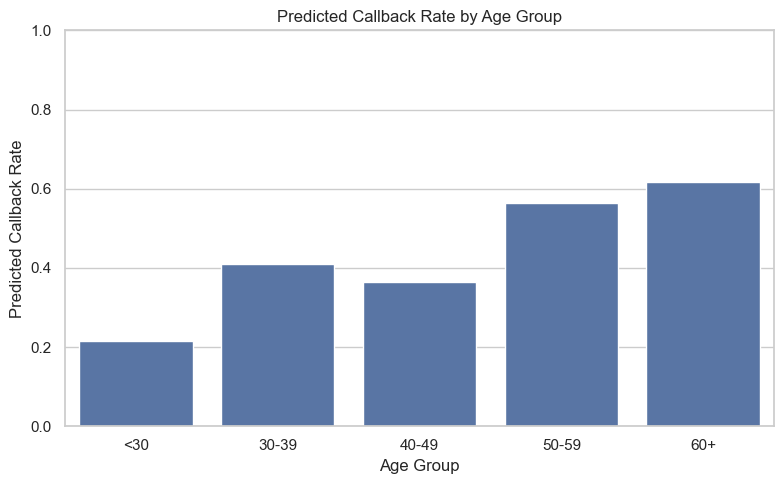

In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(data=group_outcomes, x="age_group", y="predicted_callback_rate")
plt.title("Predicted Callback Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Predicted Callback Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

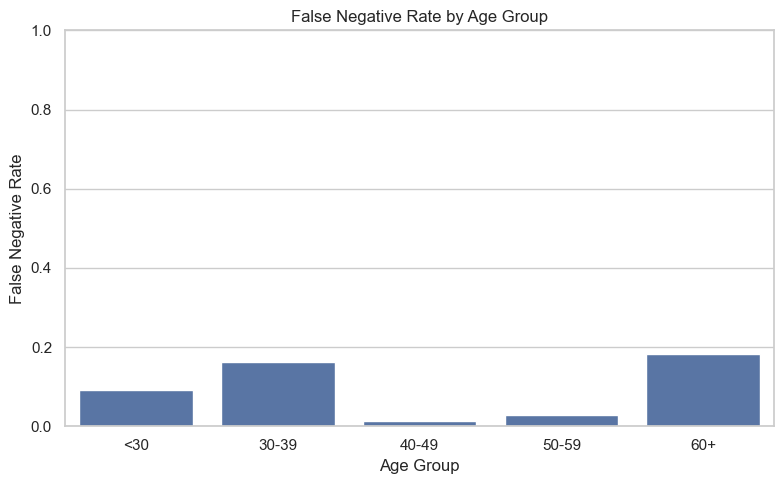

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(data=group_error_metrics, x="age_group", y="fnr")
plt.title("False Negative Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

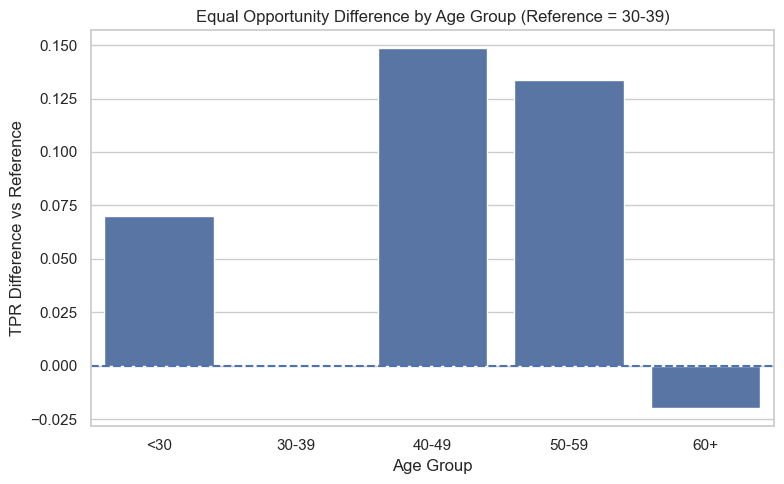

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(data=group_fairness, x="age_group", y="equal_opportunity_difference")
plt.axhline(0, linestyle="--")
plt.title(f"Equal Opportunity Difference by Age Group (Reference = {REFERENCE_GROUP})")
plt.xlabel("Age Group")
plt.ylabel("TPR Difference vs Reference")
plt.tight_layout()
plt.show()

## Interpretation and Limitations

### Interpretation

These results show whether the baseline screening model produces different output rates or error rates across age groups, despite age being excluded from model training.

Particular attention should be paid to:
- lower predicted callback rates for older groups,
- higher false negative rates for older groups, and
- negative equal opportunity differences relative to the reference group.

Such patterns would indicate that proxy features may be sufficient for the model to reproduce age-related disparities.

### Limitations

Because this experiment uses synthetic data, the results should be interpreted as a controlled demonstration of proxy leakage rather than direct evidence about any specific real-world hiring system.

## Save Fairness Outputs

### Save summary table

In [23]:
reports_tables_dir = PROJECT_ROOT / "reports" / "tables"
reports_tables_dir.mkdir(parents=True, exist_ok=True)

fairness_summary_path = reports_tables_dir / "logreg_with_grad_year_fairness_summary.csv"
fairness_summary.to_csv(fairness_summary_path, index=False)

print(f"Saved fairness summary to: {fairness_summary_path}")

Saved fairness summary to: C:\Users\Marshall\Documents\Education\ucbai\ucbai-cs-resumefilter\reports\tables\logreg_with_grad_year_fairness_summary.csv


### Save key figures

In [24]:
reports_figures_dir = PROJECT_ROOT / "reports" / "figures"
reports_figures_dir.mkdir(parents=True, exist_ok=True)

In [25]:
# Predicted callback rate
plt.figure(figsize=(8, 5))
sns.barplot(data=group_outcomes, x="age_group", y="predicted_callback_rate")
plt.title("Predicted Callback Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Predicted Callback Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(reports_figures_dir / "predicted_callback_rate_by_age_group.png")
plt.close()

# False negative rate
plt.figure(figsize=(8, 5))
sns.barplot(data=group_error_metrics, x="age_group", y="fnr")
plt.title("False Negative Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("False Negative Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(reports_figures_dir / "false_negative_rate_by_age_group.png")
plt.close()

# Equal opportunity difference
plt.figure(figsize=(8, 5))
sns.barplot(data=group_fairness, x="age_group", y="equal_opportunity_difference")
plt.axhline(0, linestyle="--")
plt.title(f"Equal Opportunity Difference by Age Group (Reference = {REFERENCE_GROUP})")
plt.xlabel("Age Group")
plt.ylabel("TPR Difference vs Reference")
plt.tight_layout()
plt.savefig(reports_figures_dir / "equal_opportunity_difference_by_age_group.png")
plt.close()

print("Saved fairness figures.")

Saved fairness figures.
